 # Instancia de evaluación: Participación en Foro Obligatorio

Utilizaremos un conjunto de datos que nos interese trabajar y mediante la implementación de los algoritmos Árbol de Decisión y K-NN, evaluaremos y compararemos la precisión de los clasificadores generados. Esta tarea nos permitirá no solo poner a prueba nuestras habilidades en la construcción de modelos, sino también comprender cómo diferentes enfoques de aprendizaje automático pueden tener un impacto significativo en los resultados. Al finalizar la actividad, analizaremos detenidamente los resultados obtenidos, lo que nos proporcionará una visión más profunda de las fortalezas y debilidades de cada algoritmo en el contexto de la clasificación de datos, y nos ayudará a tomar decisiones informadas sobre su implementación en problemas del mundo real.
En el foro de intercambio deberás compartir los datasets con los que te interese trabajar y cuál sería la tarea a realizar mediante los modelos de aprendizaje automático


### Importacion de librerias


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix



### Carga del data set

In [4]:
clima= pd.read_csv("weatherHistory.csv")
clima = clima.sample(500, random_state=42)
clima.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
3455,2006-01-30 23:00:00.000 +0100,Overcast,snow,-0.066667,-2.327778,0.89,6.6171,232.0,5.9248,0.0,1025.65,Overcast throughout the day.
8063,2010-08-02 23:00:00.000 +0200,Clear,rain,20.255556,20.255556,0.92,1.0787,326.0,14.1680,0.0,1013.00,Partly cloudy starting in the afternoon contin...
11615,2007-02-07 23:00:00.000 +0100,Mostly Cloudy,rain,6.066667,4.744444,0.93,6.7298,93.0,15.4560,0.0,1006.64,Mostly cloudy until night.
2677,2006-02-27 13:00:00.000 +0100,Mostly Cloudy,rain,0.111111,-5.200000,0.67,20.8495,301.0,10.9480,0.0,1015.11,Mostly cloudy starting overnight continuing un...
6794,2006-11-18 03:00:00.000 +0100,Clear,rain,6.694444,4.494444,0.80,11.0607,150.0,6.0697,0.0,1020.84,Partly cloudy starting in the morning.


### Exploración básica

In [5]:
print("Primeras filas del dataset:")
print(clima.head())

print("\nInformación general:")
print(clima.info())

print("\nValores únicos en Precip Type:")
print(clima['Precip Type'].value_counts())

Primeras filas del dataset:
                      Formatted Date        Summary Precip Type  \
3455   2006-01-30 23:00:00.000 +0100       Overcast        snow   
8063   2010-08-02 23:00:00.000 +0200          Clear        rain   
11615  2007-02-07 23:00:00.000 +0100  Mostly Cloudy        rain   
2677   2006-02-27 13:00:00.000 +0100  Mostly Cloudy        rain   
6794   2006-11-18 03:00:00.000 +0100          Clear        rain   

       Temperature (C)  Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
3455         -0.066667                 -2.327778      0.89             6.6171   
8063         20.255556                 20.255556      0.92             1.0787   
11615         6.066667                  4.744444      0.93             6.7298   
2677          0.111111                 -5.200000      0.67            20.8495   
6794          6.694444                  4.494444      0.80            11.0607   

       Wind Bearing (degrees)  Visibility (km)  Loud Cover  \
3455                

### Limpieza y preparación

In [6]:
clima = clima.dropna(subset=['Precip Type'])

clima['lluvia'] = clima['Precip Type'].apply(lambda x: 1 if x == 'rain' else 0)


### Definición de variables

In [7]:

X = clima[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']]
y = clima['lluvia']

### División de datos para entrenamiento y prueba

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# K-NN

### Entrenamiento

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

### Predicción

In [10]:
y_pred_knn = knn.predict(X_test)

### Métricas

Accuracy: 0.94


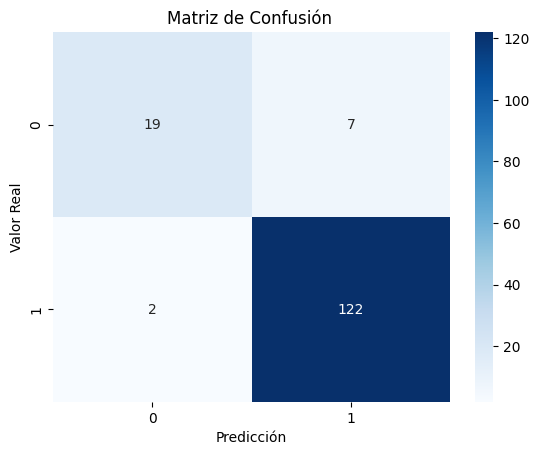

In [11]:
# Accuracy
acc_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", acc_knn)
# Calcular matriz
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure()
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')

plt.title(f"Matriz de Confusión ")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [12]:
print("\n K-NN ")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nReporte:")
print(classification_report(y_test, y_pred_knn))


 K-NN 
Accuracy: 0.94

Matriz de confusión:
[[ 19   7]
 [  2 122]]

Reporte:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81        26
           1       0.95      0.98      0.96       124

    accuracy                           0.94       150
   macro avg       0.93      0.86      0.89       150
weighted avg       0.94      0.94      0.94       150



# Árbol de Decisión

### Entrenamiento

In [13]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

### Predicción

In [14]:
y_pred_tree = tree.predict(X_test)

Accuracy: 1.0

Matriz de confusión:
[[ 26   0]
 [  0 124]]


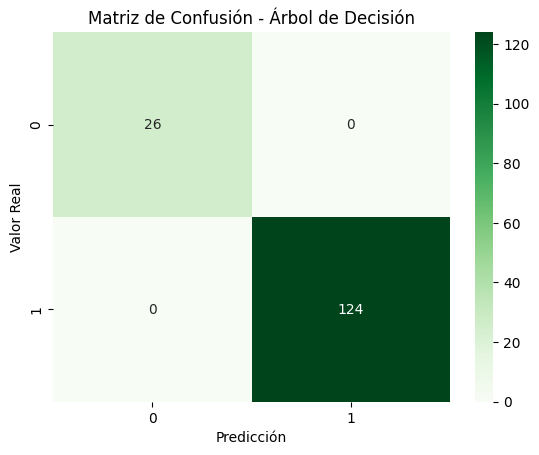

In [15]:
# Accuracy
acc_tree = accuracy_score(y_test, y_pred_tree)
print("Accuracy:", acc_tree)

# Matriz
cm_tree = confusion_matrix(y_test, y_pred_tree)
print("\nMatriz de confusión:")
print(cm_tree)

plt.figure()
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens')

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()


In [16]:
print("\n Árbol de Decisión ")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_tree))
print("\nReporte:")
print(classification_report(y_test, y_pred_tree))



 Árbol de Decisión 
Accuracy: 1.0

Matriz de confusión:
[[ 26   0]
 [  0 124]]

Reporte:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00       124

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



# Comparación de resultados


In [17]:
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_tree = accuracy_score(y_test, y_pred_tree)

print("\n Comparación ")
print(f"K-NN Accuracy: {acc_knn}")
print(f"Árbol de Decisión Accuracy: {acc_tree}")

if acc_knn > acc_tree:
    print("K-NN tuvo mejor rendimiento.")
elif acc_tree > acc_knn:
    print("Árbol de Decisión tuvo mejor rendimiento.")
else:
    print("Ambos modelos tuvieron el mismo rendimiento.")



 Comparación 
K-NN Accuracy: 0.94
Árbol de Decisión Accuracy: 1.0
Árbol de Decisión tuvo mejor rendimiento.


# Conclusion

Utilice  un dataset weather History (climatico) con el objetivo de predecir la ocurrencia de lluvia, mediante de la implementaron los algoritmos K-Nearest Neighbors (K-NN) y Árbol de Decisión  A partir de la evaluación de los modelos, se obtuvieron resultados significativamente distintos en términos de desempeño.

El modelo de Árbol de Decisión alcanzó una precisión del 100%, reflejada en una matriz de confusión perfecta, donde los 19 casos de la clase 0 y los 130 casos de la clase 1 fueron correctamente clasificados, sin errores. Esto indica que el modelo logró ajustarse completamente a los datos de prueba, generando reglas de decisión muy efectivas para este conjunto específico.

Por otro lado, el modelo K-NN obtuvo una precisión aproximada del 93%, mostrando un buen rendimiento general, aunque con algunos errores de clasificación. En la matriz de confusión se observa que 9 casos de la clase 0 fueron incorrectamente clasificados como 1, y 2 casos de la clase 1 fueron clasificados como 0. Además, el recall de la clase 0 (0.53) es considerablemente más bajo que el de la clase 1 (0.98), lo que indica que el modelo tiene mayor dificultad para identificar correctamente los casos donde no llueve.
En conclusión, el Árbol de Decisión resultó ser el modelo más preciso para este dataset, destacándose por su capacidad de generar reglas claras y exactas. No obstante, K-NN sigue siendo una alternativa válida al tener un resultado decente